In [1]:
import random
import math
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter


In [ ]:
BASE_BET = 5
bet = BASE_BET
NUMBER_OF_DECKS = 6
DECK_PEN = .25 # Percent of deck left before reshuffle
SURRENDER_ALLOWED = True
MAX_HANDS = 4          # table rule: 3 splits = 4 hands
DOUBLE_AFTER_SPLIT = True
PLAY_TIMES = 1_000_000 # number of hands played
STARTING_BANKROLL = 1_000_000


# ---- Monte Carlo harness ----
TRIALS          = 100
ROUNDS          = 1_000_000     # rounds per trial
SAMPLE_EVERY    = 1_000         # equity-curve resolution (plotting only)
BASE_SEED       = 12345
ROUNDS_PER_HOUR = 100           # for the hourly win rate
BANKROLL_UNITS  = [100, 200, 500, 1000, 2000, 5000]   # risk-of-ruin sweep, in BASE_BET units

bankroll = STARTING_BANKROLL
decks =  []
dealer_hand = []
dealer_bust = False

loss_count = 0
win_count = 0
push_count = 0
insurance_count = 0
even_money_count = 0
double_count = 0
surrender_count = 0
split_count = 0
deviation_count = 0

dealer_downcard = 0

running_count = 0
true_count = 0

WONGING_OUT = False

COUNTING_VALUES = {
    2: +1,
    3: +1,
    4: +1,
    5: +1,
    6: +1,
    7: 0,
    8: 0,
    9: 0,
    10: -1,
    11: -1
}

# Illustrious 18 (I18)
DEVIATIONS = {
    ('hard', 16, 10): ( 0, 'stand',  'hit'),
    ('hard', 15, 10): ( 4, 'stand',  'hit'),
    ('hard', 16,  9): ( 5, 'stand',  'hit'),
    ('hard', 13,  2): (-1, 'stand',  'hit'),
    ('hard', 13,  3): (-2, 'stand',  'hit'),
    ('hard', 12,  2): ( 3, 'stand',  'hit'),
    ('hard', 12,  3): ( 2, 'stand',  'hit'),
    ('hard', 12,  4): ( 0, 'stand',  'hit'),
    ('hard', 12,  5): (-2, 'stand',  'hit'),
    ('hard', 12,  6): (-1, 'stand',  'hit'),
    ('hard', 11, 11): ( 1, 'double', 'hit'),
    ('hard', 10, 10): ( 4, 'double', 'hit'),
    ('hard', 10, 11): ( 4, 'double', 'hit'),
    ('hard',  9,  2): ( 1, 'double', 'hit'),
    ('hard',  9,  7): ( 3, 'double', 'hit'),
}

def new_bet ():  # adjust counting spread here
    global bet
    if true_count >= 5:
        bet = 12 * BASE_BET
    elif true_count >= 4:
        bet = 8 * BASE_BET
    elif true_count >= 3:
        bet = 4 * BASE_BET
    elif true_count >= 2:
        bet = 2 * BASE_BET
    else: 
        bet = BASE_BET

history = []                 # one row per sample
df = pd.DataFrame()          # filled in at the end of main()


In [3]:
# ---- strategy below is the H17 chart (dealer hits soft 17) ----

def deal_card(downcard = False):
    global running_count, true_count, dealer_downcard
    if downcard:
        dealer_downcard = decks.pop()
        return dealer_downcard
    else:
        new_card = decks.pop()
        running_count += COUNTING_VALUES[new_card]
        true_count = running_count / max(len(decks) / 52, 0.5)
        return new_card

def new_hand(cards, bet_size):
    return {'cards': cards,
            'bet_size': bet_size,
            'done': False,
            'outcome': None,
            'from_split': False,
            'split_ace': False}

def reset_shoe ():
    global decks, running_count, true_count, bet
    decks = NUMBER_OF_DECKS * 4 * [2,3,4,5,6,7,8,9,10,10,10,10,11]
    random.shuffle(decks)
    running_count = 0
    true_count = 0
    bet = BASE_BET

def reset():
    global hands, dealer_bust
    dealer_hand.clear()
    dealer_bust = False
    hands = []

def deal_dealer_hand():
    dealer_hand.append(deal_card(downcard = True))
    dealer_hand.append(deal_card())

def loss(HID):
    global loss_count, bankroll
    loss_count += 1
    bankroll -= hands[HID]['bet_size']
    return

def win(HID):
    global win_count, bankroll
    win_count += 1
    bankroll += hands[HID]['bet_size']
    return

def push():
    global push_count
    push_count += 1

def insurance ():
    global bankroll, insurance_count
    insurance_count += 1
    insurance_bet = hands[0]['bet_size'] / 2
    bankroll -= insurance_bet
    if sum(dealer_hand) == 21:
        bankroll += 3 * insurance_bet

def even_money(HID):
    global even_money_count
    hands[HID]['done'] = True
    win(HID)
    hands[HID]['outcome'] = 'even_money'
    even_money_count += 1

def deal():
    new_bet()                       # the bet is decided BEFORE any card is dealt
    hands.append(new_hand([deal_card(), deal_card()], bet))
    deal_dealer_hand()
    if dealer_hand[1] == 11 and true_count >= 3:
        if sum(hands[0]['cards']) == 21:
            even_money(0)
        else:
            insurance()

def hand_kind(cards):
    """'pair', 'soft' or 'hard' - how the deviation table is keyed."""
    if len(cards) == 2 and cards[0] == cards[1]:
        return 'pair'
    elif 11 in cards:
        return 'soft'
    else:
        return 'hard'

def deviation_action(HID):
    """The Illustrious 18 play for this spot, or None to use basic strategy."""
    cards = hands[HID]['cards']
    entry = DEVIATIONS.get((hand_kind(cards), sum(cards), dealer_hand[1]))
    if entry is None:
        return None
    index, at_or_above, below = entry
    return at_or_above if true_count >= index else below

def apply_deviation(HID):
    """Take the index play if there is one and it is legal. True if it acted."""
    global deviation_count
    action = deviation_action(HID)
    if action is None:
        return False
    hand = hands[HID]
    can_double = len(hand['cards']) == 2 and (HID == 0 or DOUBLE_AFTER_SPLIT)
    if action == 'stand':
        stand(HID)
    elif action == 'hit':
        hit(HID)
    elif action == 'double' and can_double:
        double(HID)
    else:
        return False                # illegal here, fall back to basic strategy
    deviation_count += 1
    return True

def split_logic(HID):
    cards = hands[HID]['cards']
    if hands[HID]['split_ace']:                   # split aces are never re-split
        return False
    if len(cards) != 2 or cards[0] != cards[1]:   # only an untouched pair can be split
        return False
    card = cards[0]
    upcard = dealer_hand[1]
    # Illustrious 18: 10,10 is split against 5 at TC >= 5 and against 6 at TC >= 4
    if card == 10:
        return (upcard == 5 and true_count >= 5) or (upcard == 6 and true_count >= 4)
    if card in [11,8]:
        return True 
    elif card == 9 and upcard not in [7,10,11]:
        return True
    elif card == 7 and upcard <= 7:
        return True
    elif card == 6 and upcard <= 6 and (upcard > 2 or DOUBLE_AFTER_SPLIT):
        return True
    elif card == 4 and upcard in [5,6] and DOUBLE_AFTER_SPLIT:
        return True
    elif card in [3,2] and upcard <= 7 and (upcard > 3 or DOUBLE_AFTER_SPLIT):
        return True
    else: 
        return False

def split(HID):
    global split_count
    if len(hands) >= MAX_HANDS:
        return False
    if split_logic(HID):
        hand = hands[HID]
        moved = hand['cards'].pop()             # take one card off the original
        hand['cards'].append(deal_card())       # original is redrawn to right away
        hand['from_split'] = True               # neither half can be a natural any more
        # the new hand stays at one card until play() reaches it, and matches the original bet
        new = new_hand([moved], hand['bet_size'])
        new['from_split'] = True
        if moved == 11:                         # split aces take one card each and stop
            hand['split_ace'] = True
            new['split_ace'] = True
        hands.append(new)
        split_count += 1
        return True
    return False

def surrender_logic(HID):
    if not SURRENDER_ALLOWED or HID != 0:
        return False
    cards = hands[HID]['cards']
    if len(cards) != 2 or 11 in cards:           # 11 in cards means the total is soft
        return False
    total = sum(cards)
    upcard = dealer_hand[1]
    is_pair = cards[0] == cards[1]
    if is_pair:
        return cards[0] == 8 and upcard == 11    # 8,8 vs A surrenders; otherwise split it
    if total == 16 and upcard in [9,10,11]:
        return True
    elif total == 15 and upcard in [10,11]:
        return True
    elif total == 17 and upcard == 11:
        return True
    else:
        return False

def surrender(HID):
    global bankroll, surrender_count
    hand = hands[HID]
    bankroll -= hand['bet_size'] / 2
    hand['outcome'] = 'surrendered'
    hand['done'] = True
    surrender_count += 1
    
def hit(HID):
    hand = hands[HID]
    hand['cards'].append(deal_card())

def stand(HID):
    hand = hands[HID]
    hand['done'] = True

def double(HID):
    global double_count
    hand = hands[HID]
    hand['cards'].append(deal_card())
    hand['bet_size'] = hand['bet_size'] * 2
    hand['done'] = True
    double_count += 1

def blackjack(HID):
    global win_count, bankroll
    win_count += 1
    bankroll += hands[HID]['bet_size'] * 1.5     # a natural pays 3:2

def aces(HID):
    hand = hands[HID]
    hand_total = sum(hand['cards'])
    upcard = dealer_hand[1]
    if hand_total >= 20:
        stand(HID)
    elif hand_total == 19:
        if upcard == 6 and len(hand['cards']) == 2 and (HID == 0 or DOUBLE_AFTER_SPLIT):
            double(HID)
        else: 
            stand(HID)
    elif hand_total == 18:
        if upcard >= 9:
            hit(HID)
        elif upcard <= 6 and len(hand['cards']) == 2 and (HID == 0 or DOUBLE_AFTER_SPLIT):
            double(HID)
        else: stand(HID)
    elif hand_total == 17:
        if upcard in [3,4,5,6] and len(hand['cards']) == 2 and (HID == 0 or DOUBLE_AFTER_SPLIT):
            double(HID)
        else:
            hit(HID)
    elif hand_total in [16,15]:
        if upcard in [4,5,6] and len(hand['cards']) == 2 and (HID == 0 or DOUBLE_AFTER_SPLIT):
            double(HID)
        else:
            hit(HID)
    elif hand_total in [13,14] and len(hand['cards']) == 2 and (HID == 0 or DOUBLE_AFTER_SPLIT):
        if upcard in [5,6]:
            double(HID)
        else:
            hit(HID)
    else:
        hit(HID)

def standard_logic(HID):
    hand = hands[HID]
    hand_total = sum(hand['cards'])
    upcard = dealer_hand[1]
    if hand_total >= 17:
        stand(HID)
    elif hand_total >= 13:
        if upcard >= 7:
            hit(HID)
        else:
            stand(HID)
    elif hand_total == 12:
        if upcard in [4,5,6]:
            stand(HID)
        else :
            hit(HID)
    elif hand_total == 11:
        if len(hand['cards']) == 2 and (HID == 0 or DOUBLE_AFTER_SPLIT):
            double(HID)
        else:
            hit(HID)
    elif hand_total == 10:
        if upcard <= 9 and len(hand['cards']) == 2 and (HID == 0 or DOUBLE_AFTER_SPLIT):
            double(HID)
        else:
            hit(HID)
    elif hand_total == 9:
        if upcard in [3,4,5,6] and len(hand['cards']) == 2 and (HID == 0 or DOUBLE_AFTER_SPLIT):
            double(HID)
        else:
            hit(HID)
    elif hand_total == 8:
        hit(HID)
    else:
        hit(HID)

def check_if_over_21(HID):
    hand = hands[HID]
    if sum(hand['cards']) > 21:
        if 11 in hand['cards']:
            hand['cards'][hand['cards'].index(11)] = 1
        else:
            hand['done'] = True

def player_logic(HID):
    hand = hands[HID]
    if hand['done']:
        return
    if len(hand['cards']) < 2:
        hand['cards'].append(deal_card())   # split hand collects its second card now
    if hand['split_ace']:                   # a split ace gets one card, then it is finished
        hand['done'] = True
        return
    # surrender is declared before any other action, and ends the hand
    if surrender_logic(HID):
        surrender(HID)
        return
    while split(HID):                       # re-split while the redraw keeps making pairs
        pass
    if hand['split_ace']:                   # this hand just split aces
        hand['done'] = True
        return
    while not hand['done']:
        check_if_over_21(HID)
        if not apply_deviation(HID):        # index plays first, basic strategy otherwise
            if 11 in hand['cards']:
                aces(HID)
            else:
                standard_logic(HID)
        check_if_over_21(HID)

def play():
    if sum(dealer_hand) == 21:
        return
    HID = 0
    while HID < len(hands):     # len() re-read each pass, so split hands get played
        player_logic(HID)
        HID += 1

def dealer_play():
    global dealer_bust, dealer_downcard, running_count, true_count
    running_count += COUNTING_VALUES[dealer_downcard]
    true_count = running_count / max(len(decks) / 52, 0.5)
    while True:
        total = sum(dealer_hand)
        if total > 21:
            if 11 in dealer_hand:
                dealer_hand[dealer_hand.index(11)] = 1
                continue
            dealer_bust = True
            return
        soft = 11 in dealer_hand
        if total > 17 or (total == 17 and not soft):   # H17: hit soft 17
            return
        dealer_hand.append(deal_card())

def evaluate():
    dealer_total = sum(dealer_hand)
    dealer_bj = (dealer_total == 21 and len(dealer_hand) == 2)
    HID = 0
    while HID < len(hands):
        hand = hands[HID]
        if hand['outcome'] in ('surrendered', 'even_money'):
            HID += 1                 # already settled, do not pay it twice
            continue
        hand_total = sum(hand['cards'])
        # a natural is 21 on the first two cards, and never a hand that was split
        player_bj = (hand_total == 21 and len(hand['cards']) == 2
                     and not hand['from_split'])
        if player_bj and dealer_bj:
            hand['outcome'] = 'push'
        elif player_bj:
            hand['outcome'] = 'blackjack'
        elif hand_total > 21 or dealer_bj:
            hand['outcome'] = 'loss'
        elif dealer_bust or hand_total > dealer_total:
            hand['outcome'] = 'win'
        elif hand_total == dealer_total:
            hand['outcome'] = 'push'
        else:
            hand['outcome'] = 'loss'
        HID += 1

def payout():
    HID = 0
    while HID < len(hands):
        outcome = hands[HID]['outcome']
        if outcome == 'win':
            win(HID)
        elif outcome == 'blackjack':
            blackjack(HID)
        elif outcome == 'push':
            push()
        elif outcome == 'loss':
            loss(HID)
        # 'surrendered' and 'even_money' were already settled
        HID += 1

def summary():
    print(f'Bankroll: ${bankroll}')
    print(f'Win/loss amount: ${bankroll - STARTING_BANKROLL}')
    print(f'Percent change: {(((bankroll - STARTING_BANKROLL)/STARTING_BANKROLL)* 100):.2f}%')
    print('--------------------------------')
    print(f'Number of wins: {win_count}')
    print(f'Number of losses: {loss_count}')
    print(f'Number of pushes: {push_count}')
    print(f'Number of doubles: {double_count}')
    print(f'Number of Splits: {split_count}')
    print(f'Number of surrenders: {surrender_count}')
    print(f'Insurance taken: {insurance_count}')
    print(f'Even money taken: {even_money_count}')
    print(f'Index plays made: {deviation_count}')

    sns.set_theme(style="dark")
    ax = sns.lineplot(df, x = 'hand', y = 'bankroll')
    ax.xaxis.set_major_locator(MaxNLocator(10))
    ax.yaxis.set_major_locator(MaxNLocator(8))

    plt.show()

def reset_session():
    global bankroll, bet, dealer_downcard
    global loss_count, win_count, push_count, insurance_count, even_money_count
    global double_count, surrender_count, split_count, deviation_count
    bankroll = STARTING_BANKROLL
    bet = BASE_BET
    dealer_downcard = 0
    loss_count = win_count = push_count = 0
    insurance_count = even_money_count = 0
    double_count = surrender_count = split_count = deviation_count = 0
    reset_shoe()     # decks, running_count, true_count
    reset()          # hands, dealer_hand, dealer_bust


Bankroll: $1103725.0
Win/loss amount: $103725.0
Percent change: 10.37%
--------------------------------
Number of wins: 437291
Number of losses: 454668
Number of pushes: 83904
Number of doubles: 105830
Number of Splits: 28363
Number of surrenders: 52500
Insurance taken: 7591
Even money taken: 307
Index plays made: 114934


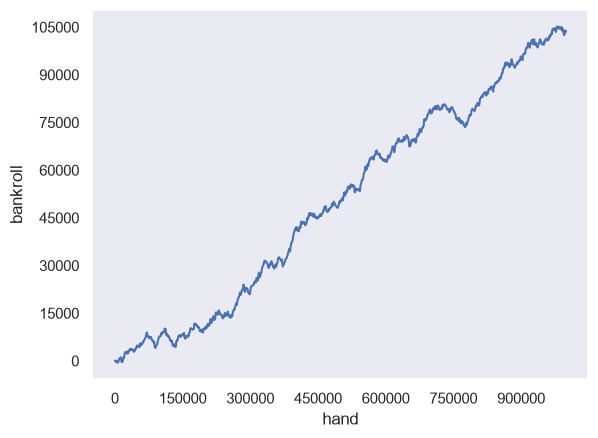

In [4]:
def main():
    global df
    random.seed(42)
    reset_session()
    history = []
    for i in range(PLAY_TIMES):
        reset()
        deal()
        play()
        dealer_play()
        evaluate()
        payout()
        if len(decks) < DECK_PEN * 52 * NUMBER_OF_DECKS or (true_count < -2 and WONGING_OUT):
            reset_shoe()
        if i % 1000 == 0:
            history.append({'hand': i, 'bankroll': bankroll - STARTING_BANKROLL})
        if bankroll <= BASE_BET:
            break
    df = pd.DataFrame(history)
    summary()

if __name__ == "__main__":
    main()

In [5]:
# ---- Monte Carlo harness: many independent trials of the same model ----


def run_trial(seed, rounds=ROUNDS, sample_every=SAMPLE_EVERY, trial_id=0):
    """One independent trial. Returns (metrics dict, equity samples).

    Deliberately runs the full horizon with no bankruptcy break: because new_bet()
    reads only true_count and never bankroll, the P&L path does not depend on the
    starting bankroll, so risk of ruin at ANY bankroll can be derived afterwards
    from min_equity.
    """
    random.seed(seed)
    reset_session()

    equity = sum_pnl = sum_sq = wagered = 0.0     # equity = cumulative P&L this trial
    peak = max_dd = min_equity = 0.0
    hands_played = 0
    samples = []

    for i in range(rounds):
        before = bankroll
        reset()
        deal()
        play()
        dealer_play()
        evaluate()
        payout()

        pnl = bankroll - before
        equity += pnl
        sum_pnl += pnl
        sum_sq += pnl * pnl
        if equity > peak:
            peak = equity
        if peak - equity > max_dd:
            max_dd = peak - equity
        if equity < min_equity:
            min_equity = equity

        for h in hands:
            hands_played += 1
            wagered += h['bet_size'] / 2 if h['outcome'] == 'surrendered' else h['bet_size']

        if len(decks) < DECK_PEN * 52 * NUMBER_OF_DECKS or (true_count < -2 and WONGING_OUT):
            reset_shoe()
        if i % sample_every == 0:
            samples.append({'trial': trial_id, 'round': i, 'pnl': equity})

    mean = sum_pnl / rounds
    var = max(sum_sq / rounds - mean * mean, 0.0)
    return {
        'trial': trial_id, 'seed': seed, 'rounds': rounds,
        'final_pnl': equity, 'wagered': wagered, 'hands': hands_played,
        'mean_pnl': mean, 'sd_pnl': math.sqrt(var),
        'min_equity': min_equity, 'max_drawdown': max_dd,
        'wins': win_count, 'losses': loss_count, 'pushes': push_count,
        'doubles': double_count, 'splits': split_count, 'surrenders': surrender_count,
        'insurance': insurance_count, 'even_money': even_money_count,
        'index_plays': deviation_count,
    }, samples


def run_experiment(trials=TRIALS, rounds=ROUNDS, base_seed=BASE_SEED, verbose=True):
    """Run `trials` independent trials. Returns (trials_df, equity_df)."""
    rows, samples = [], []
    t0 = time.time()
    for t in range(trials):
        row, sample = run_trial(base_seed + t, rounds, SAMPLE_EVERY, trial_id=t)
        rows.append(row)
        samples.extend(sample)
        if verbose and (t + 1) % 10 == 0:
            el = time.time() - t0
            left = el / (t + 1) * (trials - t - 1)
            print(f'  {t+1:>3}/{trials} trials   {el:6.0f}s elapsed, ~{left:5.0f}s left')
    # built once - pd.concat in a loop measured 213x slower
    return pd.DataFrame(rows), pd.DataFrame(samples)


   10/100 trials       53s elapsed, ~  474s left
   20/100 trials      105s elapsed, ~  421s left
   30/100 trials      158s elapsed, ~  368s left
   40/100 trials      210s elapsed, ~  315s left
   50/100 trials      262s elapsed, ~  262s left
   60/100 trials      315s elapsed, ~  210s left
   70/100 trials      367s elapsed, ~  157s left
   80/100 trials      419s elapsed, ~  105s left
   90/100 trials      472s elapsed, ~   52s left
  100/100 trials      524s elapsed, ~    0s left
100 trials x 1,000,000 rounds = 100,000,000 rounds

EXPECTATION
  EV per round        $+0.0979   (+0.0196 base bets)
  EV per 100 rounds   $+9.79
  EV per hour         $+9.79   (at 100 rounds/hr)
  Edge                +0.994% of total wagered
  95% CI on EV/round  [$+0.0945, $+0.1012]
  Average bet         $9.58 per hand

VARIANCE
  SD per round        $16.68   (3.34 base bets)
  N0 (rounds for EV to equal 1 SD)   29,035
  P(finish down)      0% of trials

FINAL P&L ACROSS TRIALS
    5th percentile   $+71

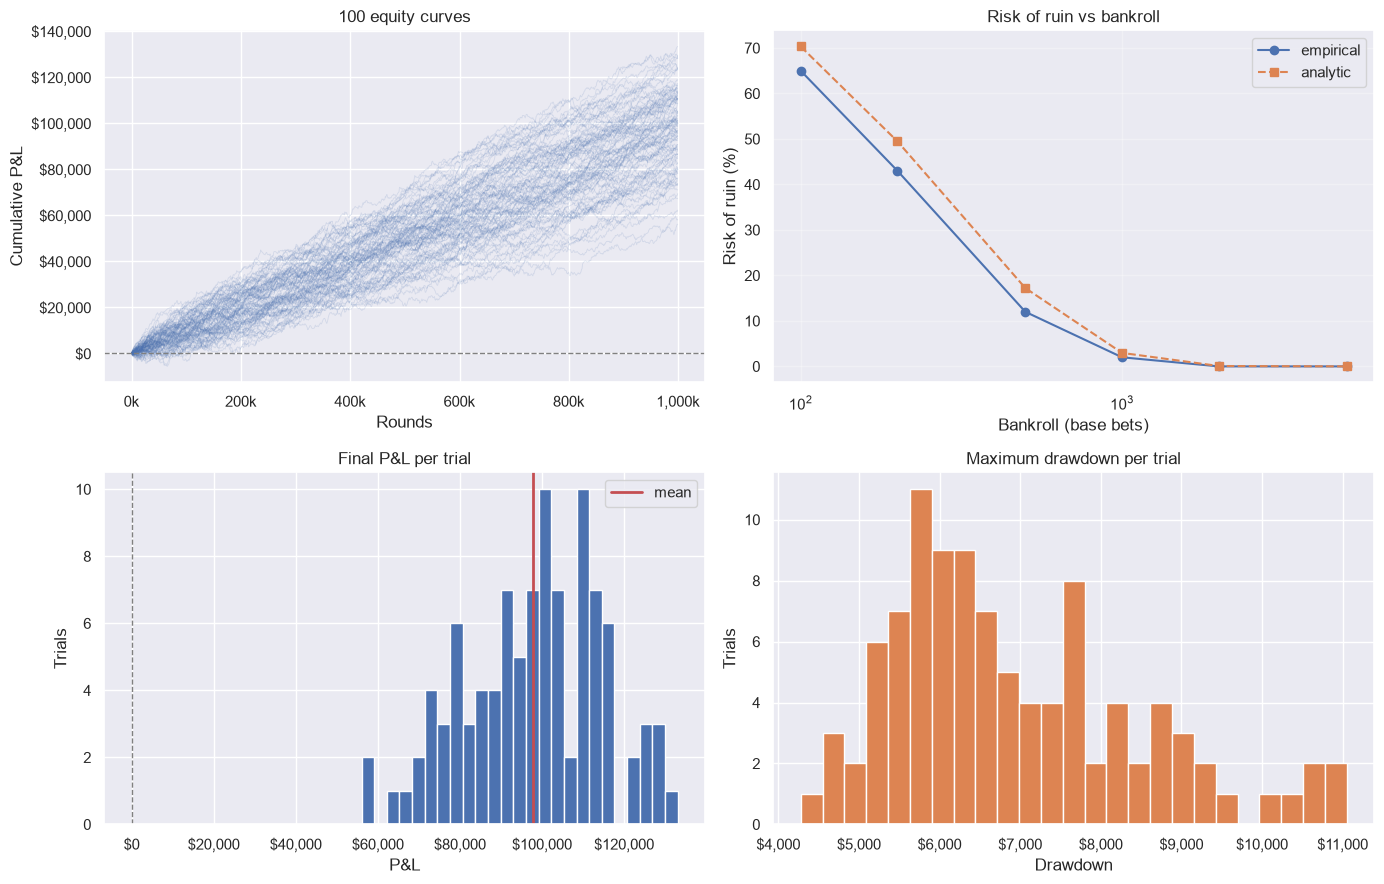

In [6]:
# ---- metrics ----
def risk_of_ruin(trials_df, bankroll_units=BANKROLL_UNITS):
    """Empirical and analytic risk of ruin for each bankroll size, in BASE_BET units.

    Empirical: a trial is ruined at bankroll B if its equity ever fell to -B.
    Analytic:  exp(-2 * mu * B / sigma**2) for a random walk, as a cross-check.
    """
    mu = trials_df['mean_pnl'].mean()
    sigma_sq = (trials_df['sd_pnl'] ** 2).mean()
    n = len(trials_df)
    rows = []
    for units in bankroll_units:
        b = units * BASE_BET
        busted = int((trials_df['min_equity'] <= -b).sum())
        analytic = math.exp(-2 * mu * b / sigma_sq) if mu > 0 else 1.0
        rows.append({
            'bankroll_units': units,
            'bankroll_$': b,
            'trials_ruined': busted,
            'empirical_RoR_%': 100 * busted / n,
            'analytic_RoR_%': 100 * min(analytic, 1.0),
        })
    return pd.DataFrame(rows)


def analyse(trials_df):
    n = len(trials_df)
    rounds = int(trials_df['rounds'].iloc[0])
    per_trial_ev = trials_df['final_pnl'] / rounds        # $ per round, one value per trial

    ev_round = per_trial_ev.mean()
    sd_round = math.sqrt((trials_df['sd_pnl'] ** 2).mean())
    se_ev = per_trial_ev.std(ddof=1) / math.sqrt(n)
    edge = trials_df['final_pnl'].sum() / trials_df['wagered'].sum() * 100
    n0 = (sd_round / ev_round) ** 2 if ev_round > 0 else float('inf')

    print(f'{n} trials x {rounds:,} rounds = {n*rounds:,} rounds\n')
    print('EXPECTATION')
    print(f'  EV per round        ${ev_round:+.4f}   ({ev_round/BASE_BET:+.4f} base bets)')
    print(f'  EV per 100 rounds   ${ev_round*100:+.2f}')
    print(f'  EV per hour         ${ev_round*ROUNDS_PER_HOUR:+.2f}   (at {ROUNDS_PER_HOUR} rounds/hr)')
    print(f'  Edge                {edge:+.3f}% of total wagered')
    print(f'  95% CI on EV/round  [${ev_round-1.984*se_ev:+.4f}, ${ev_round+1.984*se_ev:+.4f}]')
    print(f'  Average bet         ${trials_df["wagered"].sum()/trials_df["hands"].sum():.2f} per hand')
    print()
    print('VARIANCE')
    print(f'  SD per round        ${sd_round:.2f}   ({sd_round/BASE_BET:.2f} base bets)')
    print(f'  N0 (rounds for EV to equal 1 SD)   {n0:,.0f}')
    print(f'  P(finish down)      {100*(trials_df["final_pnl"] < 0).mean():.0f}% of trials')
    print()
    print('FINAL P&L ACROSS TRIALS')
    for q in (0.05, 0.25, 0.50, 0.75, 0.95):
        print(f'  {int(q*100):>3}th percentile   ${trials_df["final_pnl"].quantile(q):+,.0f}')
    print(f'  worst / best        ${trials_df["final_pnl"].min():+,.0f} / ${trials_df["final_pnl"].max():+,.0f}')
    print()
    print('DRAWDOWN (peak to trough within a trial)')
    print(f'  median              ${trials_df["max_drawdown"].median():,.0f}'
          f'   ({trials_df["max_drawdown"].median()/BASE_BET:,.0f} base bets)')
    print(f'  95th percentile     ${trials_df["max_drawdown"].quantile(0.95):,.0f}')
    print(f'  worst               ${trials_df["max_drawdown"].max():,.0f}')
    print()
    print('RISK OF RUIN')
    ror = risk_of_ruin(trials_df)
    for _, r in ror.iterrows():
        emp = (f'<{100/n:.0f}%' if r['trials_ruined'] <= 1
               else f'{r["empirical_RoR_%"]:.0f}%')
        print(f'  {int(r["bankroll_units"]):>5} units (${int(r["bankroll_$"]):>7,})   '
              f'empirical {emp:>5}  ({int(r["trials_ruined"])}/{n} trials)   '
              f'analytic {r["analytic_RoR_%"]:6.2f}%')
    print(f'\n  note: with {n} trials any RoR below {100/n:.0f}% is indistinguishable from zero.')
    return ror


def plot_experiment(trials_df, equity_df, ror):
    sns.set_theme(style="darkgrid")
    money = FuncFormatter(lambda v, p: f'${v:,.0f}')
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    ax = axes[0][0]
    for _, g in equity_df.groupby('trial'):
        ax.plot(g['round'], g['pnl'], lw=0.6, alpha=0.15, color='C0')
    ax.axhline(0, ls='--', lw=1, color='grey')
    ax.set_title(f'{len(trials_df)} equity curves')
    ax.set_xlabel('Rounds'); ax.set_ylabel('Cumulative P&L')
    ax.xaxis.set_major_locator(MaxNLocator(6)); ax.yaxis.set_major_locator(MaxNLocator(8))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, p: f'{v/1000:,.0f}k'))
    ax.yaxis.set_major_formatter(money)

    ax = axes[0][1]
    ax.plot(ror['bankroll_units'], ror['empirical_RoR_%'], 'o-', label='empirical')
    ax.plot(ror['bankroll_units'], ror['analytic_RoR_%'], 's--', label='analytic')
    ax.set_xscale('log')
    ax.set_title('Risk of ruin vs bankroll')
    ax.set_xlabel('Bankroll (base bets)'); ax.set_ylabel('Risk of ruin (%)')
    ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1][0]
    ax.hist(trials_df['final_pnl'], bins=25, color='C0', edgecolor='white')
    ax.axvline(0, ls='--', lw=1, color='grey')
    ax.axvline(trials_df['final_pnl'].mean(), lw=2, color='C3', label='mean')
    ax.set_title('Final P&L per trial'); ax.set_xlabel('P&L'); ax.set_ylabel('Trials')
    ax.xaxis.set_major_formatter(money); ax.legend()

    ax = axes[1][1]
    ax.hist(trials_df['max_drawdown'], bins=25, color='C1', edgecolor='white')
    ax.set_title('Maximum drawdown per trial'); ax.set_xlabel('Drawdown'); ax.set_ylabel('Trials')
    ax.xaxis.set_major_formatter(money)

    plt.tight_layout()
    plt.show()


trials_df, equity_df = run_experiment()
ror = analyse(trials_df)
plot_experiment(trials_df, equity_df, ror)
